In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
txn = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
nav['date'] = pd.to_datetime(nav['date'])
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

In [5]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [6]:
risk_metrics = []

for code in nav['amfi_code'].unique():

    df = nav[nav['amfi_code'] == code]

    returns = df['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        risk_metrics.append({
            'amfi_code': code,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })

risk_df = pd.DataFrame(risk_metrics)

print(risk_df.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [7]:
risk_df.to_csv("../reports/var_cvar_report.csv", index=False)

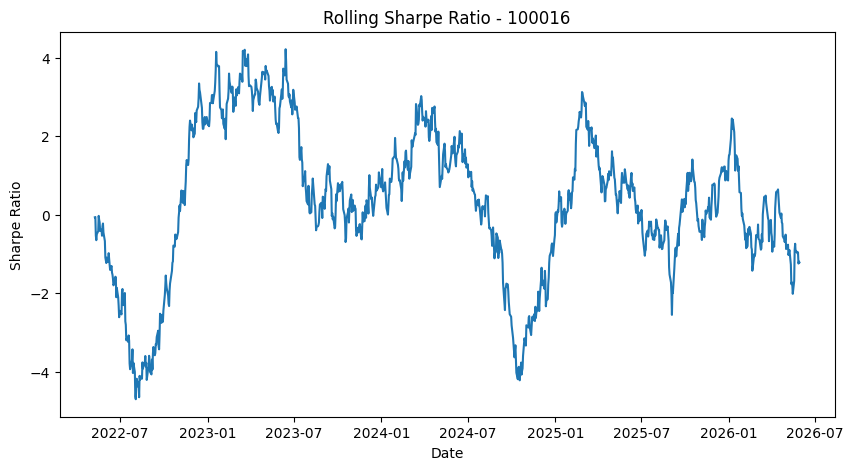

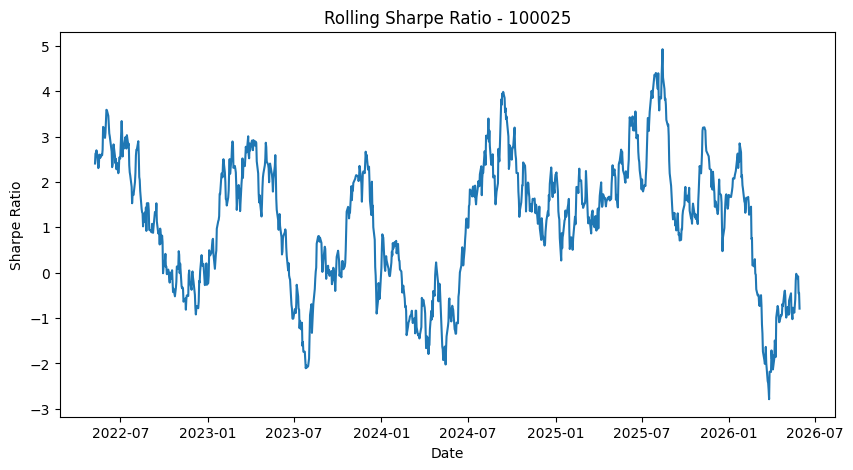

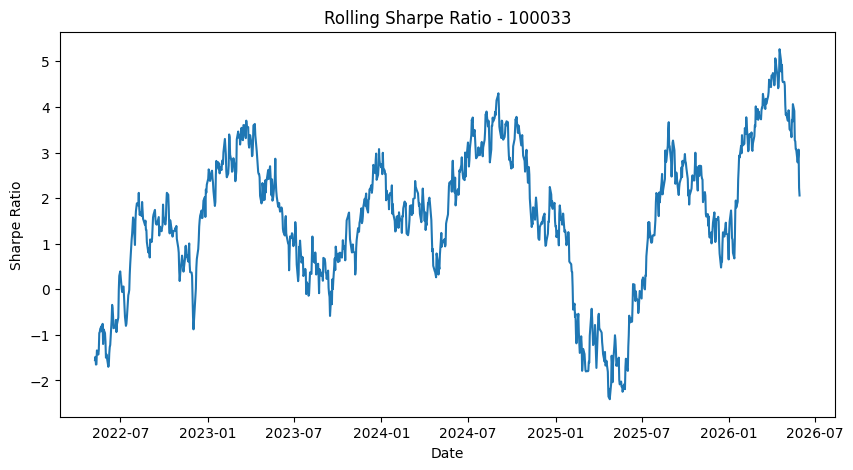

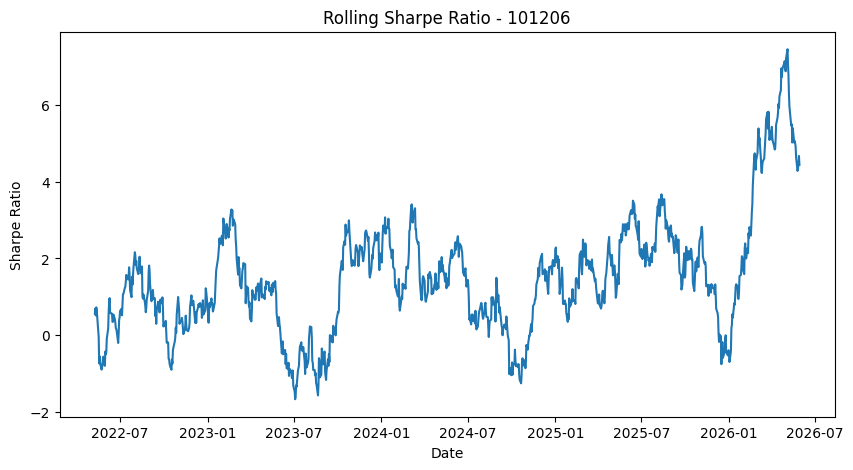

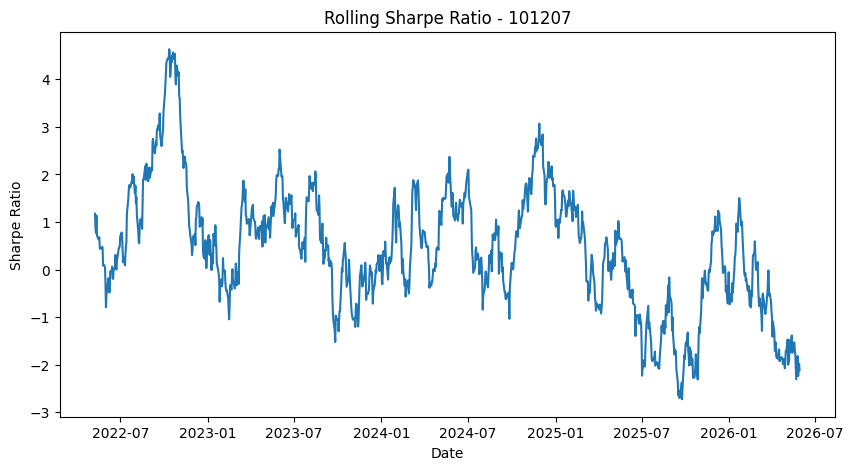

In [8]:
key_funds = nav['amfi_code'].unique()[:5]

for code in key_funds:

    df = nav[nav['amfi_code'] == code].copy()

    rolling_sharpe = (
        df['daily_return'].rolling(90).mean() /
        df['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    plt.figure(figsize=(10,5))

    plt.plot(df['date'], rolling_sharpe)

    plt.title(f'Rolling Sharpe Ratio - {code}')

    plt.xlabel("Date")
    plt.ylabel("Sharpe Ratio")

    plt.show()

In [9]:
plt.savefig("../reports/rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>

In [10]:
txn['year'] = txn['transaction_date'].dt.year

cohort = txn.groupby('year').agg({
    'amount_inr': ['mean', 'sum']
})

print(cohort)

         amount_inr            
               mean         sum
year                           
2024  107739.476605  2500633252
2025  106704.345527  1020947178


In [11]:
sip = txn[txn['transaction_type'] == 'SIP']

sip = sip.sort_values(['investor_id', 'transaction_date'])

sip['gap_days'] = sip.groupby('investor_id')['transaction_date'].diff().dt.days

risk_investors = sip.groupby('investor_id')['gap_days'].mean().reset_index()

risk_investors['status'] = np.where(
    risk_investors['gap_days'] > 35,
    'At-Risk',
    'Active'
)

print(risk_investors.head())

  investor_id  gap_days   status
0   INV000001      76.0  At-Risk
1   INV000002     207.0  At-Risk
2   INV000003     238.0  At-Risk
3   INV000004      85.4  At-Risk
4   INV000005      14.0   Active


In [12]:
holdings['hhi'] = (holdings['weight_pct'] / 100) ** 2

hhi = holdings.groupby('amfi_code')['hhi'].sum().reset_index()

print(hhi.head())


   amfi_code       hhi
0     100016  0.139534
1     100033  0.147592
2     101206  0.129332
3     101207  0.200700
4     102885  0.174709


In [14]:
perf.to_csv("data/processed/scheme_performance_cleaned.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data\processed'